X_train : (874, 106) | X_test : (219, 106)
y_train : (874,) | y_test : (219,)

🚀 Entraînement XGBoost...
AUC: 0.9908
              precision    recall  f1-score   support

           0       0.99      1.00      1.00       163
           1       1.00      0.98      0.99        56

    accuracy                           1.00       219
   macro avg       1.00      0.99      0.99       219
weighted avg       1.00      1.00      1.00       219


🚀 Entraînement LightGBM...
AUC: 0.9917
              precision    recall  f1-score   support

           0       0.99      1.00      1.00       163
           1       1.00      0.98      0.99        56

    accuracy                           1.00       219
   macro avg       1.00      0.99      0.99       219
weighted avg       1.00      1.00      1.00       219


🚀 Entraînement RandomForest...
AUC: 0.9856
              precision    recall  f1-score   support

           0       0.99      0.98      0.99       163
           1       0.95      0.98   

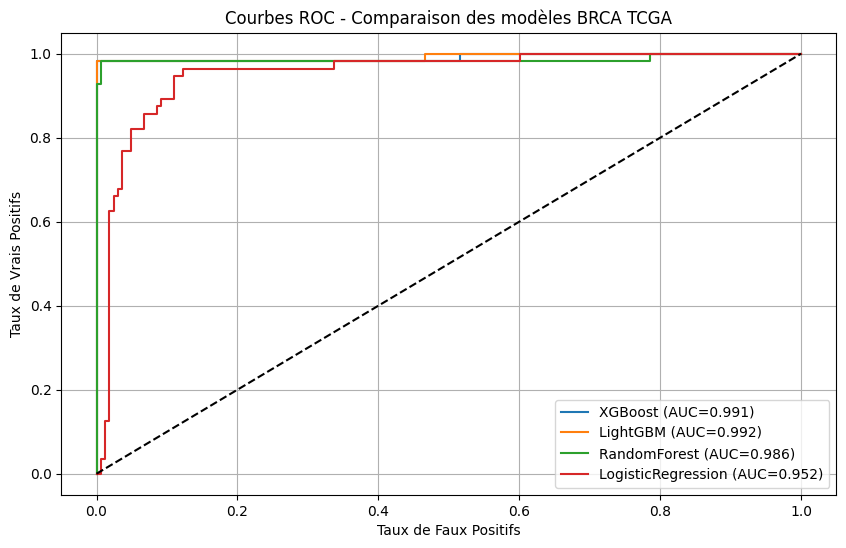


🔍 Analyse SHAP...


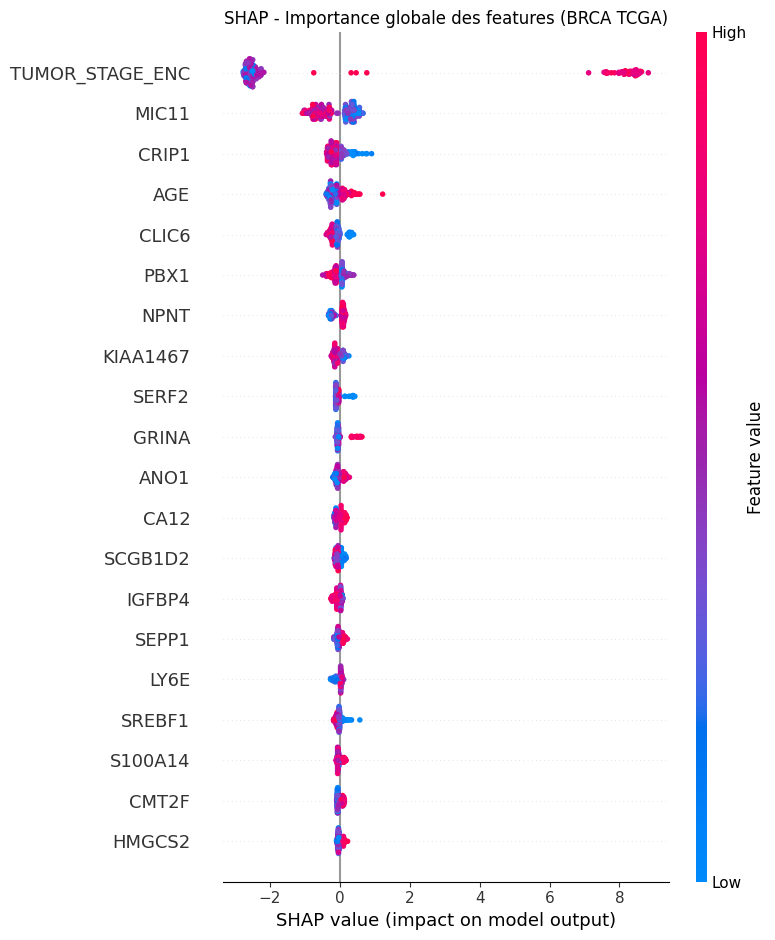

<Figure size 1000x600 with 0 Axes>

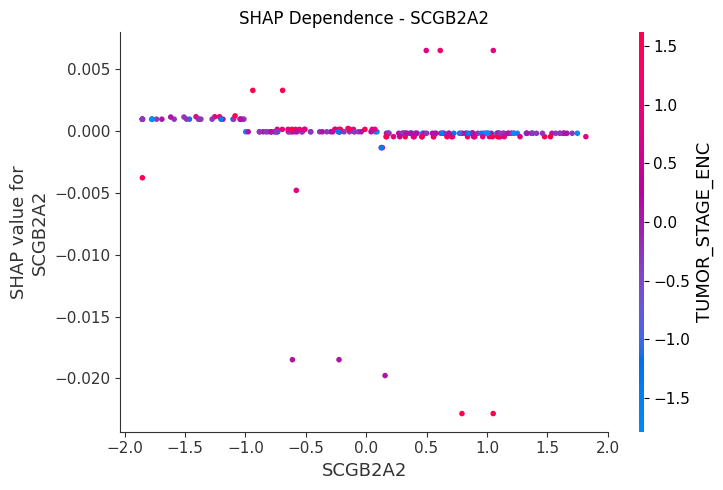


🔍 Analyse LIME...


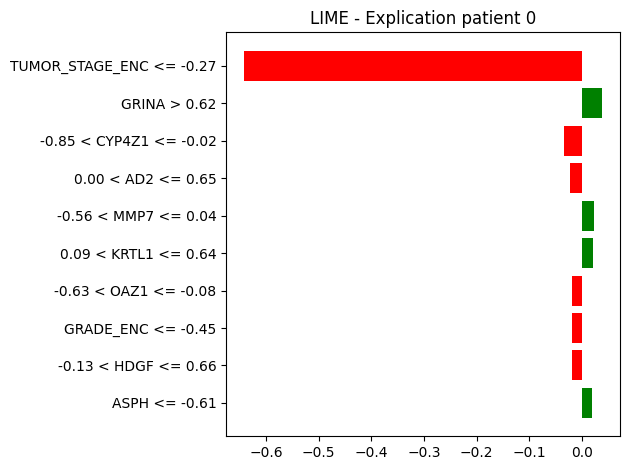

Prédiction : Sans complication
Réel       : Sans complication
✅ Modèles sauvegardés dans : C:\Users\nidha\Desktop\xai_clinical_prediction\models


In [ ]:
# Cellule 1
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import joblib
from pathlib import Path
from sklearn.metrics import (
    classification_report, roc_auc_score, roc_curve, 
    precision_recall_curve, confusion_matrix, average_precision_score
)
import xgboost as xgb
import lightgbm as lgb
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
import warnings
warnings.filterwarnings('ignore')

PROCESSED_DIR = Path('../data/processed')
MODELS_DIR = Path('../models')
FIGURES_DIR = Path('../figures')
REPORTS_DIR = Path('../reports')
for d in [MODELS_DIR, FIGURES_DIR, REPORTS_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print("="*70)
print("MODÉLISATION ET EXPLAINABILITY")
print("="*70)

# Cellule 2 : Chargement
X_train = np.load(PROCESSED_DIR / 'X_train.npy')
X_val = np.load(PROCESSED_DIR / 'X_val.npy')
X_test = np.load(PROCESSED_DIR / 'X_test.npy')
y_train = np.load(PROCESSED_DIR / 'y_train.npy')
y_val = np.load(PROCESSED_DIR / 'y_val.npy')
y_test = np.load(PROCESSED_DIR / 'y_test.npy')

feature_names = joblib.load(PROCESSED_DIR / 'selected_features.joblib')
scaler = joblib.load(PROCESSED_DIR / 'scaler.joblib')

print(f"Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}")

# Cellule 3 : Entraînement
print("\n🧠 Entraînement des modèles")

models = {
    'XGBoost': xgb.XGBClassifier(
        n_estimators=100, max_depth=5, learning_rate=0.1,
        random_state=42, eval_metric='logloss', use_label_encoder=False
    ),
    'LightGBM': lgb.LGBMClassifier(
        n_estimators=100, max_depth=5, learning_rate=0.1,
        random_state=42, verbose=-1
    ),
    'RandomForest': RandomForestClassifier(
        n_estimators=100, max_depth=10, random_state=42
    ),
    'LogisticRegression': LogisticRegression(
        max_iter=1000, random_state=42
    )
}

results = {}

for name, model in models.items():
    print(f"\n{'='*40}")
    print(f"Entraînement: {name}")
    
    model.fit(X_train, y_train)
    
    # Évaluation sur tous les sets
    sets = {
        'Train': (X_train, y_train),
        'Val': (X_val, y_val),
        'Test': (X_test, y_test)
    }
    
    metrics = {'model': model}
    for set_name, (X, y) in sets.items():
        y_pred = model.predict(X)
        y_proba = model.predict_proba(X)[:, 1]
        
        metrics[f'{set_name.lower()}_auc'] = roc_auc_score(y, y_proba)
        metrics[f'{set_name.lower()}_acc'] = (y_pred == y).mean()
        
        if set_name == 'Test':
            metrics['test_precision'] = classification_report(y, y_pred, output_dict=True)['1']['precision']
            metrics['test_recall'] = classification_report(y, y_pred, output_dict=True)['1']['recall']
            metrics['test_f1'] = classification_report(y, y_pred, output_dict=True)['1']['f1-score']
            metrics['test_avg_precision'] = average_precision_score(y, y_proba)
    
    results[name] = metrics
    
    print(f"Train AUC: {metrics['train_auc']:.3f}")
    print(f"Val AUC:   {metrics['val_auc']:.3f}")
    print(f"Test AUC:  {metrics['test_auc']:.3f}")
    print(f"Test F1:   {metrics['test_f1']:.3f}")

# Cellule 4 : Comparaison
comparison = pd.DataFrame({
    name: {k: v for k, v in m.items() if k != 'model'}
    for name, m in results.items()
}).T

print("\n📊 Comparaison:")
print(comparison[['train_auc', 'val_auc', 'test_auc', 'test_f1']])

# ROC Curves
plt.figure(figsize=(10, 8))
for name, metrics in results.items():
    model = metrics['model']
    y_proba = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc = metrics['test_auc']
    plt.plot(fpr, tpr, linewidth=2, label=f"{name} (AUC={auc:.3f})")

plt.plot([0, 1], [0, 1], 'k--', label='Random')
plt.xlabel('Taux de Faux Positifs', fontsize=12)
plt.ylabel('Taux de Vrais Positifs', fontsize=12)
plt.title('Courbes ROC - Comparaison des modèles', fontsize=14)
plt.legend(loc='lower right', fontsize=10)
plt.grid(True, alpha=0.3)
plt.savefig(FIGURES_DIR / '03_roc_curves.png', dpi=300, bbox_inches='tight')
plt.show()

# Sauvegarder tous les modèles
for name, metrics in results.items():
    joblib.dump(metrics['model'], MODELS_DIR / f'{name.lower()}_model.joblib')

# Cellule 5 : SHAP
best_name = comparison['test_auc'].idxmax()
best_model = results[best_name]['model']
print(f"\n🏆 Meilleur modèle: {best_name}")

print("\n🔍 SHAP Explanations")

explainer = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(X_test)

if isinstance(shap_values, list):
    shap_values_class1 = shap_values[1]
else:
    shap_values_class1 = shap_values

# Summary plot
plt.figure(figsize=(12, 10))
shap.summary_plot(shap_values_class1, X_test, feature_names=feature_names, show=False)
plt.title(f'SHAP Global Importance ({best_name})', fontsize=14)
plt.tight_layout()
plt.savefig(FIGURES_DIR / '03_shap_summary.png', dpi=300, bbox_inches='tight')
plt.show()

# Top features
shap_importance = pd.DataFrame({
    'feature': feature_names,
    'shap_importance': np.abs(shap_values_class1).mean(axis=0)
}).sort_values('shap_importance', ascending=False)

shap_importance.to_csv(REPORTS_DIR / 'shap_importance.csv', index=False)
print("\nTop 10 features SHAP:")
print(shap_importance.head(10))

# Waterfall pour 3 patients
for i in range(min(3, len(X_test))):
    plt.figure(figsize=(10, 8))
    shap.waterfall_plot(shap.Explanation(
        values=shap_values_class1[i],
        base_values=explainer.expected_value[1] if isinstance(explainer.expected_value, list) else explainer.expected_value,
        data=X_test[i],
        feature_names=feature_names
    ), show=False)
    plt.title(f'SHAP Waterfall - Patient {i}')
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / f'03_shap_waterfall_{i}.png', dpi=300, bbox_inches='tight')
    plt.show()

# Cellule 6 : LIME
try:
    from lime.lime_tabular import LimeTabularExplainer
    
    lime_explainer = LimeTabularExplainer(
        X_train, feature_names=feature_names,
        class_names=['Faible risque', 'Haut risque'], mode='classification'
    )
    
    exp = lime_explainer.explain_instance(
        X_test[0], best_model.predict_proba, num_features=10
    )
    
    fig = exp.as_pyplot_figure()
    plt.title('LIME - Explication Patient 0')
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / '03_lime_explanation.png', dpi=300, bbox_inches='tight')
    plt.show()
except ImportError:
    print("LIME non installé")

print("\n✅ Modélisation terminée!")